# Gradient Descent
This notebook implements batch gradient descent, stochastic gradient descent, and mini-batch gradient descent. It visualizes loss curves and convergence behavior. 

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import SGDClassifier

sns.set_theme()
plt.rcParams["figure.figsize"] = (10, 7)
np.random.seed(42)

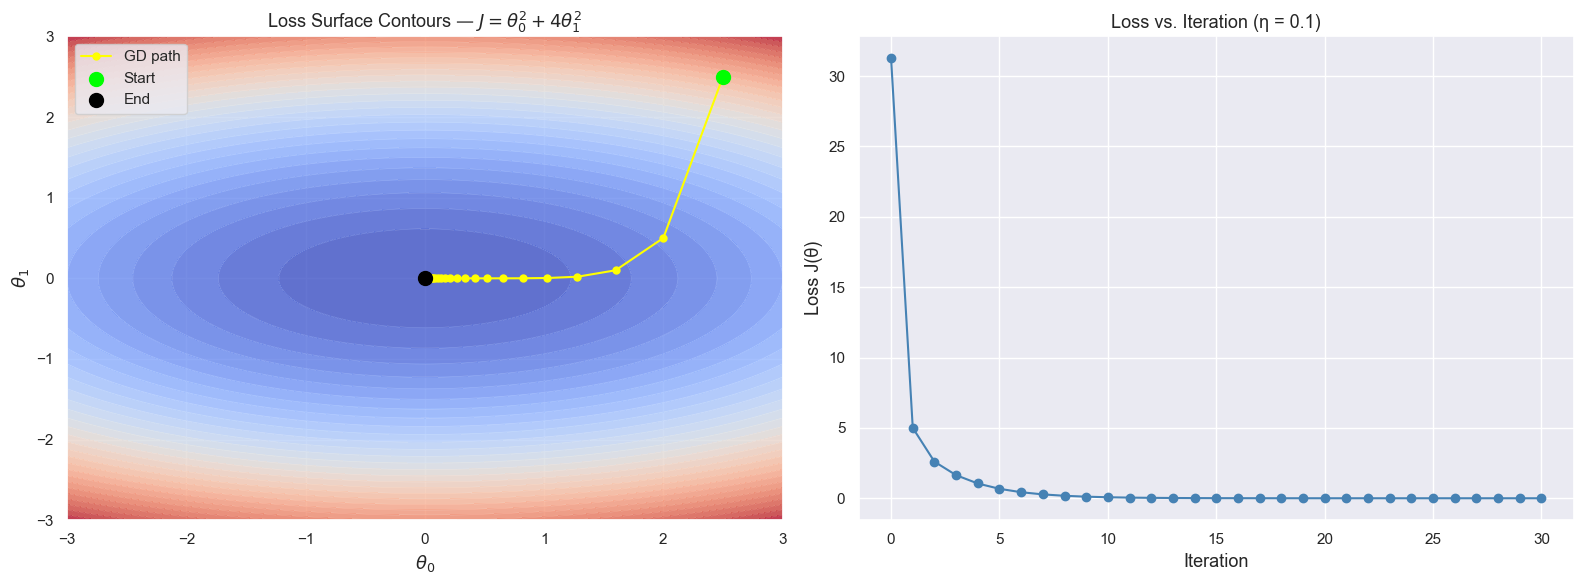

In [2]:
# --- 2D loss surface visualisation ---
def J(t0, t1):
    return t0**2 + 4 * t1**2

def grad_J(t0, t1):
    return np.array([2 * t0, 8 * t1])

# Build grid
t0_vals = np.linspace(-3, 3, 200)
t1_vals = np.linspace(-3, 3, 200)
T0, T1  = np.meshgrid(t0_vals, t1_vals)
Z       = J(T0, T1)

# Run gradient descent on the bowl
eta    = 0.1
theta  = np.array([2.5, 2.5])
path   = [theta.copy()]
for _ in range(30):
    theta = theta - eta * grad_J(*theta)
    path.append(theta.copy())
path = np.array(path)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Contour plot
axes[0].contourf(T0, T1, Z, levels=30, cmap="coolwarm", alpha=0.8)
axes[0].contour( T0, T1, Z, levels=30, colors="white", alpha=0.3, linewidths=0.5)
axes[0].plot(path[:, 0], path[:, 1], "o-", color="yellow",
             markersize=5, linewidth=1.5, label="GD path")
axes[0].scatter(*path[0],  color="lime",  s=100, zorder=5, label="Start")
axes[0].scatter(*path[-1], color="black", s=100, zorder=5, label="End")
axes[0].set_xlabel(r"$\theta_0$", fontsize=13)
axes[0].set_ylabel(r"$\theta_1$", fontsize=13)
axes[0].set_title(r"Loss Surface Contours — $J = \theta_0^2 + 4\theta_1^2$", fontsize=13)
axes[0].legend()

# Loss vs. iteration
loss_curve = [J(*p) for p in path]
axes[1].plot(loss_curve, marker="o", color="steelblue")
axes[1].set_xlabel("Iteration", fontsize=13)
axes[1].set_ylabel("Loss J(θ)", fontsize=13)
axes[1].set_title("Loss vs. Iteration (η = 0.1)", fontsize=13)

plt.tight_layout()
plt.show()

---

## 2. Load & Prepare the Wine Dataset

Gradient descent shines on continuous optimisation problems. We will use it to fit a **Logistic Regression** classifier on the Wine dataset.

Because Logistic Regression with gradient descent requires numeric stability, we **standardise** all features to zero mean and unit variance before training.

---

In [3]:
data = load_wine()

X_df = pd.DataFrame(data.data, columns=data.feature_names)
y_s  = pd.Series(data.target, name="cultivar")

target_names  = list(data.target_names)
class_mapping = {i: name for i, name in enumerate(target_names)}

print("Feature matrix shape:", X_df.shape)
print("Target shape        :", y_s.shape)
print("Classes             :", target_names)
print("\nClass distribution:")
print(y_s.value_counts().rename(index=class_mapping))

Feature matrix shape: (178, 13)
Target shape        : (178,)
Classes             : [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]

Class distribution:
cultivar
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


In [4]:
X = X_df.to_numpy()
y = y_s.to_numpy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.33, stratify=y, random_state=42
)

# Standardise (fit scaler on training data only)
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print("Training set:", X_train.shape)
print("Test set    :", X_test.shape)
print(f"\nPost-scaling — train mean ≈ {X_train.mean():.4f}, std ≈ {X_train.std():.4f}")

Training set: (119, 13)
Test set    : (59, 13)

Post-scaling — train mean ≈ 0.0000, std ≈ 1.0000


---

## 3. Softmax (Multi-Class) Logistic Regression via Gradient Descent

### Model

For a $K$-class problem with feature vector $\mathbf{x} \in \mathbb{R}^p$ and weight matrix $\mathbf{W} \in \mathbb{R}^{K \times p}$:

$$P(y = k \mid \mathbf{x}) = \frac{e^{\mathbf{w}_k^\top \mathbf{x}}}{\sum_{j=1}^{K} e^{\mathbf{w}_j^\top \mathbf{x}}} \quad \text{(softmax)}$$

### Loss — Cross-Entropy

$$J(\mathbf{W}) = -\frac{1}{n} \sum_{i=1}^{n} \sum_{k=1}^{K} y_{ik} \log \hat{p}_{ik}$$

where $y_{ik} = 1$ if sample $i$ belongs to class $k$ (one-hot encoding).

### Gradient

$$\nabla_{\mathbf{W}} J = \frac{1}{n} (\hat{\mathbf{P}} - \mathbf{Y})^\top \mathbf{X}$$

where $\hat{\mathbf{P}}$ is the matrix of predicted probabilities and $\mathbf{Y}$ is the one-hot label matrix.

---

In [5]:
# ── Helper functions ──────────────────────────────────────────────────────────

def softmax(Z):
    """Numerically stable row-wise softmax."""
    Z_shifted = Z - Z.max(axis=1, keepdims=True)
    exp_Z = np.exp(Z_shifted)
    return exp_Z / exp_Z.sum(axis=1, keepdims=True)

def one_hot(y, K):
    """One-hot encode labels y into an (n, K) matrix."""
    n = len(y)
    Y = np.zeros((n, K))
    Y[np.arange(n), y] = 1
    return Y

def cross_entropy_loss(P_hat, Y_oh):
    """Mean cross-entropy loss."""
    n = len(Y_oh)
    return -np.sum(Y_oh * np.log(P_hat + 1e-15)) / n

def predict(X, W):
    """Return predicted class labels."""
    Z = X @ W.T
    P = softmax(Z)
    return np.argmax(P, axis=1)

print("Helper functions defined.")

Helper functions defined.


---

## 4. Batch Gradient Descent

**Batch GD** computes the gradient using the **entire training set** at every step. This gives a precise, low-variance gradient estimate but can be slow for large datasets.

$$\boldsymbol{W}^{(t+1)} = \boldsymbol{W}^{(t)} - \eta \cdot \frac{1}{n}(\hat{\mathbf{P}} - \mathbf{Y})^\top \mathbf{X}$$

---

In [6]:
def batch_gradient_descent(X, y, eta=0.1, n_epochs=500, verbose=True):
    """
    Softmax Logistic Regression via Batch Gradient Descent.
    Returns W (weights), loss history, accuracy history.
    """
    n, p = X.shape
    K    = len(np.unique(y))
    W    = np.zeros((K, p))       # weight matrix: K × p
    Y_oh = one_hot(y, K)

    loss_history = []
    acc_history  = []

    for epoch in range(n_epochs):
        Z     = X @ W.T           # (n, K)
        P_hat = softmax(Z)        # (n, K)

        loss  = cross_entropy_loss(P_hat, Y_oh)
        grad  = (P_hat - Y_oh).T @ X / n   # (K, p)

        W    -= eta * grad

        acc   = accuracy_score(y, np.argmax(P_hat, axis=1))
        loss_history.append(loss)
        acc_history.append(acc)

        if verbose and (epoch % 100 == 0 or epoch == n_epochs - 1):
            print(f"  Epoch {epoch:>4d} | Loss: {loss:.4f} | Train Acc: {acc:.4f}")

    return W, loss_history, acc_history


print("Running Batch Gradient Descent...")
W_batch, loss_batch, acc_batch = batch_gradient_descent(
    X_train, y_train, eta=0.1, n_epochs=500
)

train_acc_batch = acc_batch[-1]
test_acc_batch  = accuracy_score(y_test, predict(X_test, W_batch))
print(f"\nFinal train accuracy : {train_acc_batch:.4f}")
print(f"Final test  accuracy : {test_acc_batch:.4f}")

Running Batch Gradient Descent...
  Epoch    0 | Loss: 1.0986 | Train Acc: 0.3277
  Epoch  100 | Loss: 0.0933 | Train Acc: 0.9832
  Epoch  200 | Loss: 0.0601 | Train Acc: 0.9916
  Epoch  300 | Loss: 0.0458 | Train Acc: 0.9916
  Epoch  400 | Loss: 0.0374 | Train Acc: 0.9916
  Epoch  499 | Loss: 0.0319 | Train Acc: 1.0000

Final train accuracy : 1.0000
Final test  accuracy : 0.9831


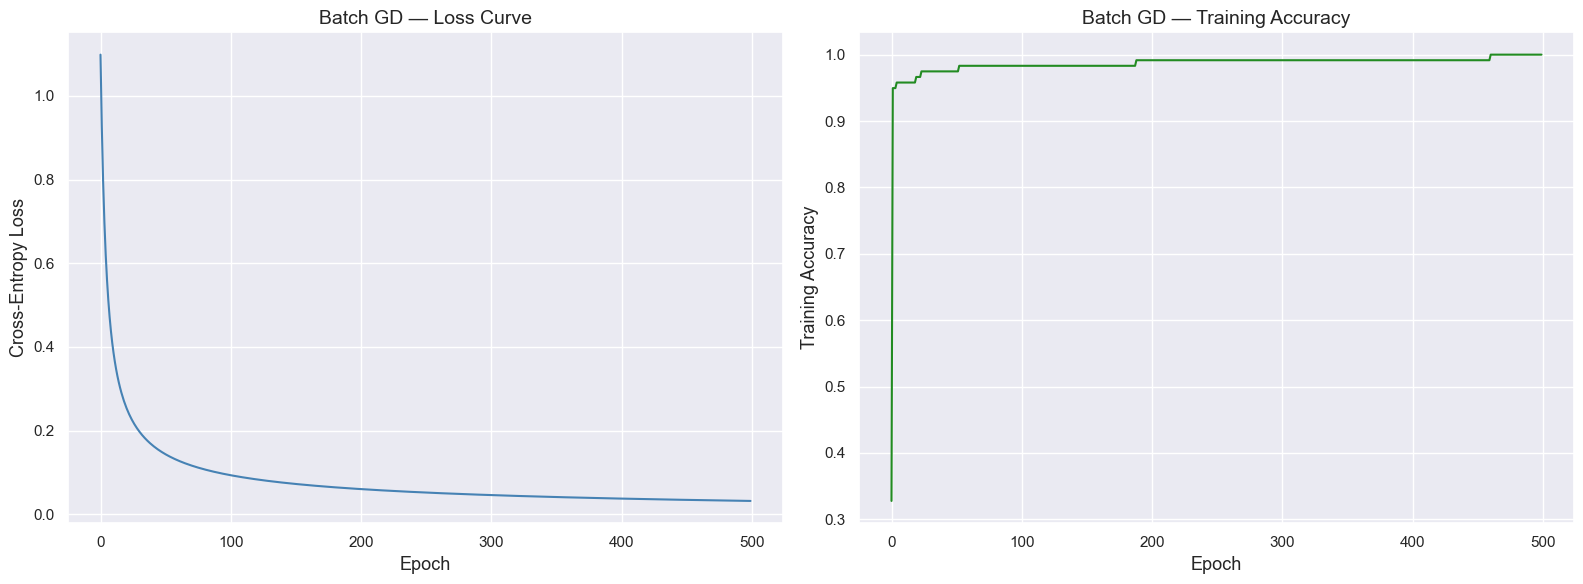

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(loss_batch, color="steelblue")
axes[0].set_xlabel("Epoch", fontsize=13)
axes[0].set_ylabel("Cross-Entropy Loss", fontsize=13)
axes[0].set_title("Batch GD — Loss Curve", fontsize=14)

axes[1].plot(acc_batch, color="forestgreen")
axes[1].set_xlabel("Epoch", fontsize=13)
axes[1].set_ylabel("Training Accuracy", fontsize=13)
axes[1].set_title("Batch GD — Training Accuracy", fontsize=14)

plt.tight_layout()
plt.show()

---

## 5. Stochastic Gradient Descent (SGD)

**SGD** computes the gradient using a **single randomly chosen sample** per step. This introduces noise into the update, which can help escape shallow local minima and saddle points, but leads to a noisy loss curve.

$$\boldsymbol{W}^{(t+1)} = \boldsymbol{W}^{(t)} - \eta \cdot \nabla_{\mathbf{W}} J_i$$

where $i$ is a randomly selected training index.

---

In [8]:
def stochastic_gradient_descent(X, y, eta=0.01, n_epochs=100, verbose=True):
    """
    Softmax Logistic Regression via Stochastic Gradient Descent.
    One random sample per update step.
    """
    n, p = X.shape
    K    = len(np.unique(y))
    W    = np.zeros((K, p))
    Y_oh = one_hot(y, K)

    loss_history = []   # recorded once per epoch (full-batch eval)
    acc_history  = []

    for epoch in range(n_epochs):
        # Shuffle indices each epoch
        indices = np.random.permutation(n)
        for i in indices:
            xi    = X[i:i+1]           # (1, p)
            yi_oh = Y_oh[i:i+1]        # (1, K)

            Z     = xi @ W.T
            P_hat = softmax(Z)
            grad  = (P_hat - yi_oh).T @ xi   # (K, p)
            W    -= eta * grad

        # Epoch-level metrics (full batch)
        Z_full    = X @ W.T
        P_full    = softmax(Z_full)
        loss      = cross_entropy_loss(P_full, Y_oh)
        acc       = accuracy_score(y, np.argmax(P_full, axis=1))
        loss_history.append(loss)
        acc_history.append(acc)

        if verbose and (epoch % 20 == 0 or epoch == n_epochs - 1):
            print(f"  Epoch {epoch:>3d} | Loss: {loss:.4f} | Train Acc: {acc:.4f}")

    return W, loss_history, acc_history


print("Running Stochastic Gradient Descent...")
W_sgd, loss_sgd, acc_sgd = stochastic_gradient_descent(
    X_train, y_train, eta=0.01, n_epochs=100
)

train_acc_sgd = acc_sgd[-1]
test_acc_sgd  = accuracy_score(y_test, predict(X_test, W_sgd))
print(f"\nFinal train accuracy : {train_acc_sgd:.4f}")
print(f"Final test  accuracy : {test_acc_sgd:.4f}")

Running Stochastic Gradient Descent...
  Epoch   0 | Loss: 0.3532 | Train Acc: 0.9580
  Epoch  20 | Loss: 0.0517 | Train Acc: 0.9916
  Epoch  40 | Loss: 0.0322 | Train Acc: 1.0000
  Epoch  60 | Loss: 0.0238 | Train Acc: 1.0000
  Epoch  80 | Loss: 0.0191 | Train Acc: 1.0000
  Epoch  99 | Loss: 0.0161 | Train Acc: 1.0000

Final train accuracy : 1.0000
Final test  accuracy : 0.9831


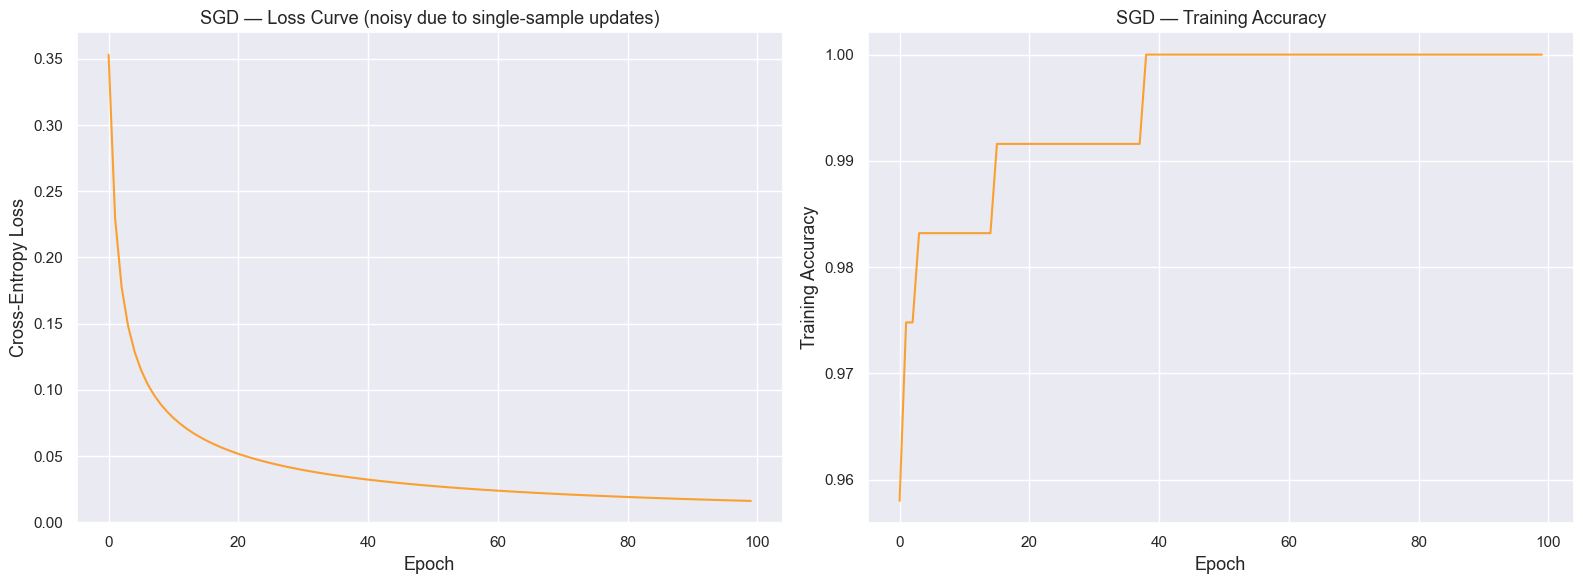

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(loss_sgd, color="darkorange", alpha=0.8)
axes[0].set_xlabel("Epoch", fontsize=13)
axes[0].set_ylabel("Cross-Entropy Loss", fontsize=13)
axes[0].set_title("SGD — Loss Curve (noisy due to single-sample updates)", fontsize=13)

axes[1].plot(acc_sgd, color="darkorange", alpha=0.8)
axes[1].set_xlabel("Epoch", fontsize=13)
axes[1].set_ylabel("Training Accuracy", fontsize=13)
axes[1].set_title("SGD — Training Accuracy", fontsize=13)

plt.tight_layout()
plt.show()

---

## 6. Mini-Batch Gradient Descent

**Mini-Batch GD** is a compromise: compute the gradient on a small random **batch** of $B$ samples at each step. This balances the stability of Batch GD with the speed and noise benefits of SGD.

$$\boldsymbol{W}^{(t+1)} = \boldsymbol{W}^{(t)} - \eta \cdot \frac{1}{B} \sum_{i \in \mathcal{B}} \nabla_{\mathbf{W}} J_i$$

In practice, mini-batch GD (with $B \in [16, 256]$) is the default choice for neural networks.

---

In [10]:
def minibatch_gradient_descent(X, y, eta=0.05, n_epochs=200, batch_size=16, verbose=True):
    """
    Softmax Logistic Regression via Mini-Batch Gradient Descent.
    """
    n, p = X.shape
    K    = len(np.unique(y))
    W    = np.zeros((K, p))
    Y_oh = one_hot(y, K)

    loss_history = []
    acc_history  = []

    for epoch in range(n_epochs):
        indices = np.random.permutation(n)
        for start in range(0, n, batch_size):
            batch_idx = indices[start : start + batch_size]
            X_b  = X[batch_idx]
            Y_b  = Y_oh[batch_idx]

            Z     = X_b @ W.T
            P_hat = softmax(Z)
            grad  = (P_hat - Y_b).T @ X_b / len(batch_idx)
            W    -= eta * grad

        # Epoch-level metrics
        Z_full = X @ W.T
        P_full = softmax(Z_full)
        loss   = cross_entropy_loss(P_full, Y_oh)
        acc    = accuracy_score(y, np.argmax(P_full, axis=1))
        loss_history.append(loss)
        acc_history.append(acc)

        if verbose and (epoch % 50 == 0 or epoch == n_epochs - 1):
            print(f"  Epoch {epoch:>3d} | Loss: {loss:.4f} | Train Acc: {acc:.4f}")

    return W, loss_history, acc_history


print("Running Mini-Batch Gradient Descent (batch_size=16)...")
W_mb, loss_mb, acc_mb = minibatch_gradient_descent(
    X_train, y_train, eta=0.05, n_epochs=200, batch_size=16
)

train_acc_mb = acc_mb[-1]
test_acc_mb  = accuracy_score(y_test, predict(X_test, W_mb))
print(f"\nFinal train accuracy : {train_acc_mb:.4f}")
print(f"Final test  accuracy : {test_acc_mb:.4f}")

Running Mini-Batch Gradient Descent (batch_size=16)...
  Epoch   0 | Loss: 0.6263 | Train Acc: 0.9496
  Epoch  50 | Loss: 0.0592 | Train Acc: 0.9832
  Epoch 100 | Loss: 0.0369 | Train Acc: 0.9916
  Epoch 150 | Loss: 0.0274 | Train Acc: 1.0000
  Epoch 199 | Loss: 0.0221 | Train Acc: 1.0000

Final train accuracy : 1.0000
Final test  accuracy : 0.9831


---

## 7. Comparing Batch, SGD, and Mini-Batch

We overlay the loss and accuracy curves of all three variants on the same axes to compare convergence speed and smoothness.

---

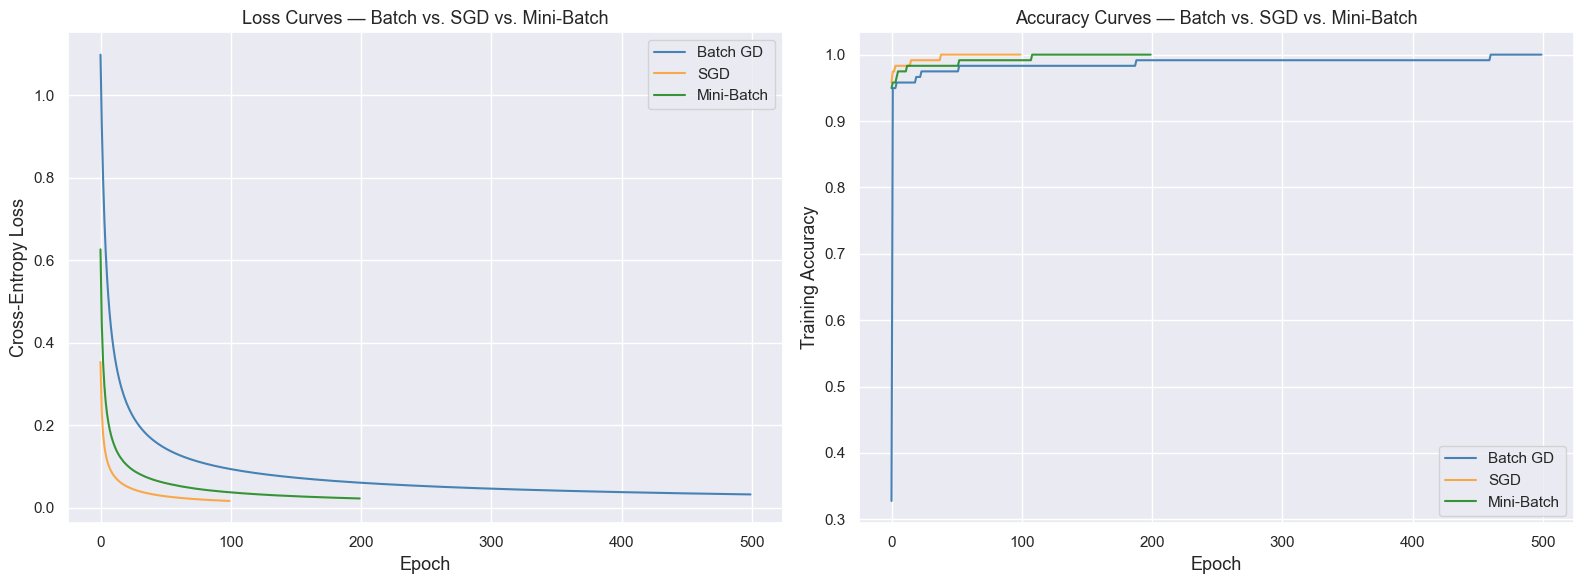

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Normalise epoch axis to the same length for fair comparison
epochs_batch = range(len(loss_batch))
epochs_sgd   = range(len(loss_sgd))
epochs_mb    = range(len(loss_mb))

# Loss
axes[0].plot(epochs_batch, loss_batch,  color="steelblue",   label="Batch GD")
axes[0].plot(epochs_sgd,   loss_sgd,    color="darkorange",  label="SGD",        alpha=0.7)
axes[0].plot(epochs_mb,    loss_mb,     color="forestgreen", label="Mini-Batch", alpha=0.9)
axes[0].set_xlabel("Epoch", fontsize=13)
axes[0].set_ylabel("Cross-Entropy Loss", fontsize=13)
axes[0].set_title("Loss Curves — Batch vs. SGD vs. Mini-Batch", fontsize=13)
axes[0].legend(fontsize=11)

# Accuracy
axes[1].plot(epochs_batch, acc_batch,  color="steelblue",   label="Batch GD")
axes[1].plot(epochs_sgd,   acc_sgd,    color="darkorange",  label="SGD",        alpha=0.7)
axes[1].plot(epochs_mb,    acc_mb,     color="forestgreen", label="Mini-Batch", alpha=0.9)
axes[1].set_xlabel("Epoch", fontsize=13)
axes[1].set_ylabel("Training Accuracy", fontsize=13)
axes[1].set_title("Accuracy Curves — Batch vs. SGD vs. Mini-Batch", fontsize=13)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

---

## 8. The Effect of Learning Rate

The learning rate $\eta$ is the most important hyperparameter in gradient descent.

- **Too small** → very slow convergence; may get stuck.
- **Too large** → overshoots the minimum; loss may diverge.
- **Just right** → fast, stable convergence.

We sweep several learning rates and observe the resulting loss curves.

---

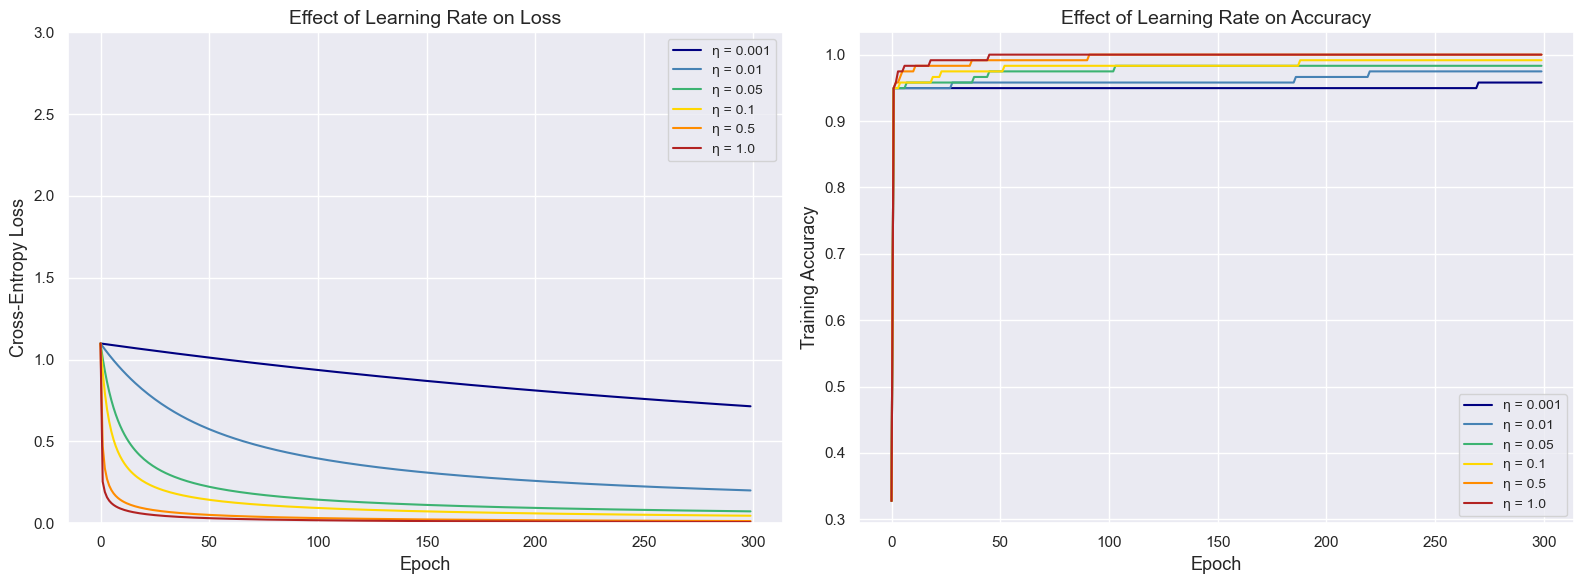

In [12]:
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
colors_lr      = ["navy", "steelblue", "mediumseagreen", "gold", "darkorange", "firebrick"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for eta, color in zip(learning_rates, colors_lr):
    _, loss_hist, acc_hist = batch_gradient_descent(
        X_train, y_train, eta=eta, n_epochs=300, verbose=False
    )
    axes[0].plot(loss_hist, color=color, label=f"η = {eta}")
    axes[1].plot(acc_hist,  color=color, label=f"η = {eta}")

axes[0].set_xlabel("Epoch", fontsize=13)
axes[0].set_ylabel("Cross-Entropy Loss", fontsize=13)
axes[0].set_title("Effect of Learning Rate on Loss", fontsize=14)
axes[0].legend(fontsize=10)
axes[0].set_ylim(0, 3)

axes[1].set_xlabel("Epoch", fontsize=13)
axes[1].set_ylabel("Training Accuracy", fontsize=13)
axes[1].set_title("Effect of Learning Rate on Accuracy", fontsize=14)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

---

## 9. Momentum

### Concept

Plain gradient descent can be slow when the loss surface has **ravines** — regions where the gradient is large in one direction but small in the direction toward the minimum. **Momentum** accumulates a velocity vector $\mathbf{v}$ in the direction of persistent gradients, dampening oscillations and accelerating descent.

$$\mathbf{v}^{(t+1)} = \beta \, \mathbf{v}^{(t)} + \eta \, \nabla J(\boldsymbol{W}^{(t)})$$
$$\boldsymbol{W}^{(t+1)} = \boldsymbol{W}^{(t)} - \mathbf{v}^{(t+1)}$$

where $\beta \in [0, 1)$ is the **momentum coefficient** (typically 0.9). When $\beta = 0$, this reduces to plain gradient descent.

---

In [13]:
def batch_gd_momentum(X, y, eta=0.05, beta=0.9, n_epochs=300, verbose=True):
    """
    Batch Gradient Descent with Momentum.
    """
    n, p = X.shape
    K    = len(np.unique(y))
    W    = np.zeros((K, p))
    v    = np.zeros_like(W)    # velocity
    Y_oh = one_hot(y, K)

    loss_history = []
    acc_history  = []

    for epoch in range(n_epochs):
        Z     = X @ W.T
        P_hat = softmax(Z)
        grad  = (P_hat - Y_oh).T @ X / n

        v     = beta * v + eta * grad
        W    -= v

        loss  = cross_entropy_loss(P_hat, Y_oh)
        acc   = accuracy_score(y, np.argmax(P_hat, axis=1))
        loss_history.append(loss)
        acc_history.append(acc)

        if verbose and (epoch % 100 == 0 or epoch == n_epochs - 1):
            print(f"  Epoch {epoch:>4d} | Loss: {loss:.4f} | Train Acc: {acc:.4f}")

    return W, loss_history, acc_history


print("Running Batch GD with Momentum (β=0.9)...")
W_mom, loss_mom, acc_mom = batch_gd_momentum(
    X_train, y_train, eta=0.05, beta=0.9, n_epochs=300
)

test_acc_mom = accuracy_score(y_test, predict(X_test, W_mom))
print(f"\nFinal test accuracy (momentum) : {test_acc_mom:.4f}")
print(f"Final test accuracy (plain GD) : {test_acc_batch:.4f}")

Running Batch GD with Momentum (β=0.9)...
  Epoch    0 | Loss: 1.0986 | Train Acc: 0.3277
  Epoch  100 | Loss: 0.0227 | Train Acc: 1.0000
  Epoch  200 | Loss: 0.0150 | Train Acc: 1.0000
  Epoch  299 | Loss: 0.0114 | Train Acc: 1.0000

Final test accuracy (momentum) : 0.9831
Final test accuracy (plain GD) : 0.9831


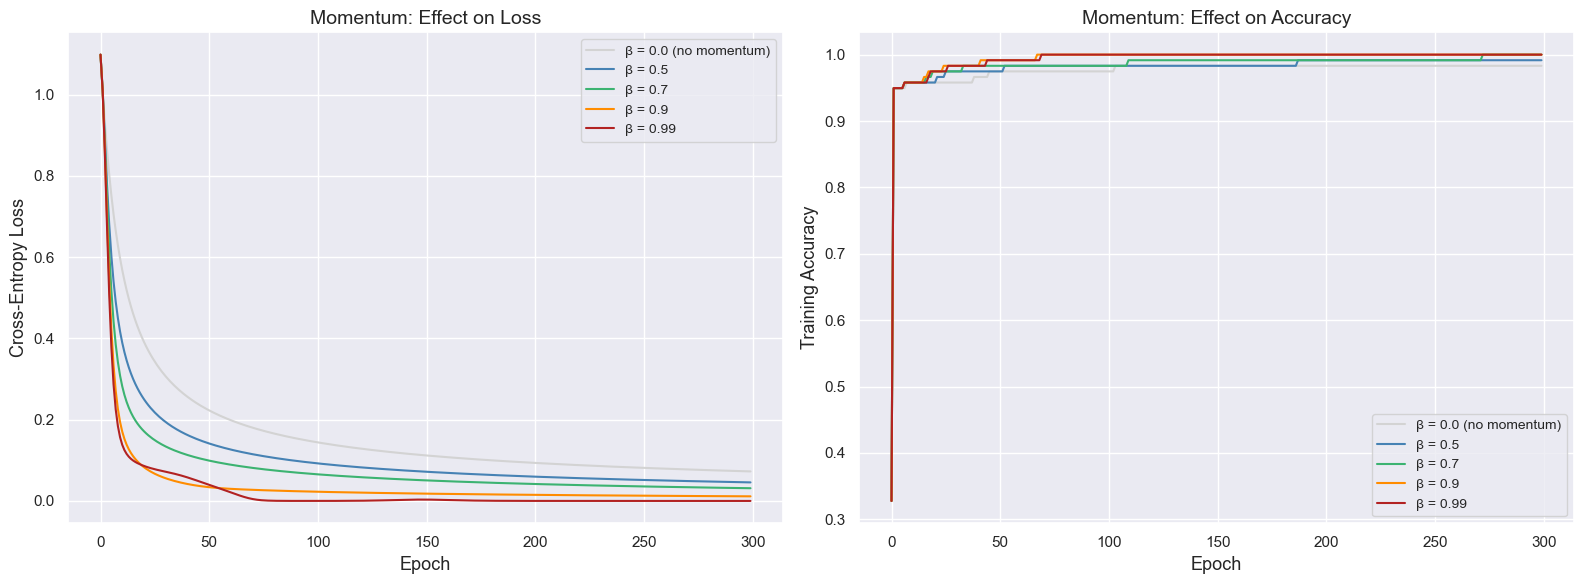

In [14]:
# Momentum β sweep
betas  = [0.0, 0.5, 0.7, 0.9, 0.99]
cols_b = ["lightgray", "steelblue", "mediumseagreen", "darkorange", "firebrick"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for beta, color in zip(betas, cols_b):
    _, lh, ah = batch_gd_momentum(
        X_train, y_train, eta=0.05, beta=beta, n_epochs=300, verbose=False
    )
    label = f"β = {beta}" + (" (no momentum)" if beta == 0.0 else "")
    axes[0].plot(lh, color=color, label=label)
    axes[1].plot(ah, color=color, label=label)

for ax, title, ylabel in [
    (axes[0], "Momentum: Effect on Loss",     "Cross-Entropy Loss"),
    (axes[1], "Momentum: Effect on Accuracy", "Training Accuracy"),
]:
    ax.set_xlabel("Epoch", fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_title(title, fontsize=14)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

---

## 10. Evaluate the Best From-Scratch Model

Using the best-performing from-scratch variant (Batch GD, η = 0.1, 500 epochs), we produce a full evaluation on the held-out test set.

---

In [15]:
y_pred_best = predict(X_test, W_batch)

print(f"Test accuracy (Batch GD from scratch): {test_acc_batch:.4f}\n")
print(classification_report(y_test, y_pred_best, target_names=target_names))

Test accuracy (Batch GD from scratch): 0.9831

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        20
     class_1       1.00      0.96      0.98        23
     class_2       0.94      1.00      0.97        16

    accuracy                           0.98        59
   macro avg       0.98      0.99      0.98        59
weighted avg       0.98      0.98      0.98        59



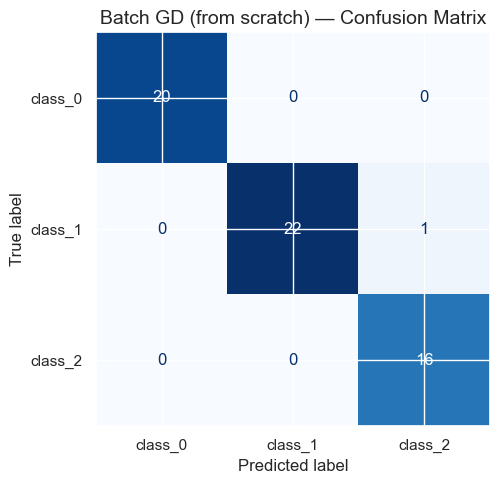

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
cm_gd = confusion_matrix(y_test, y_pred_best)
disp  = ConfusionMatrixDisplay(cm_gd, display_labels=target_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Batch GD (from scratch) — Confusion Matrix", fontsize=14)
plt.tight_layout()
plt.show()

---

## 11. Comparison: From-Scratch GD vs. sklearn SGDClassifier

`sklearn`'s `SGDClassifier` implements regularised stochastic gradient descent with several loss functions. We compare it against our from-scratch implementations as a sanity check.

---

In [17]:
# sklearn SGDClassifier
sklearn_sgd = SGDClassifier(
    loss="log_loss",    # cross-entropy → logistic regression
    max_iter=300,
    eta0=0.01,
    learning_rate="constant",
    random_state=42
)
sklearn_sgd.fit(X_train, y_train)
sklearn_acc = accuracy_score(y_test, sklearn_sgd.predict(X_test))

print(f"sklearn SGDClassifier test accuracy : {sklearn_acc:.4f}")
print(f"From-scratch Batch GD test accuracy : {test_acc_batch:.4f}")
print(f"From-scratch SGD test accuracy      : {test_acc_sgd:.4f}")
print(f"From-scratch Mini-Batch test accuracy: {test_acc_mb:.4f}")
print(f"From-scratch Momentum test accuracy : {test_acc_mom:.4f}")

sklearn SGDClassifier test accuracy : 0.9831
From-scratch Batch GD test accuracy : 0.9831
From-scratch SGD test accuracy      : 0.9831
From-scratch Mini-Batch test accuracy: 0.9831
From-scratch Momentum test accuracy : 0.9831


---

## 12. Final Summary of All Variants

---

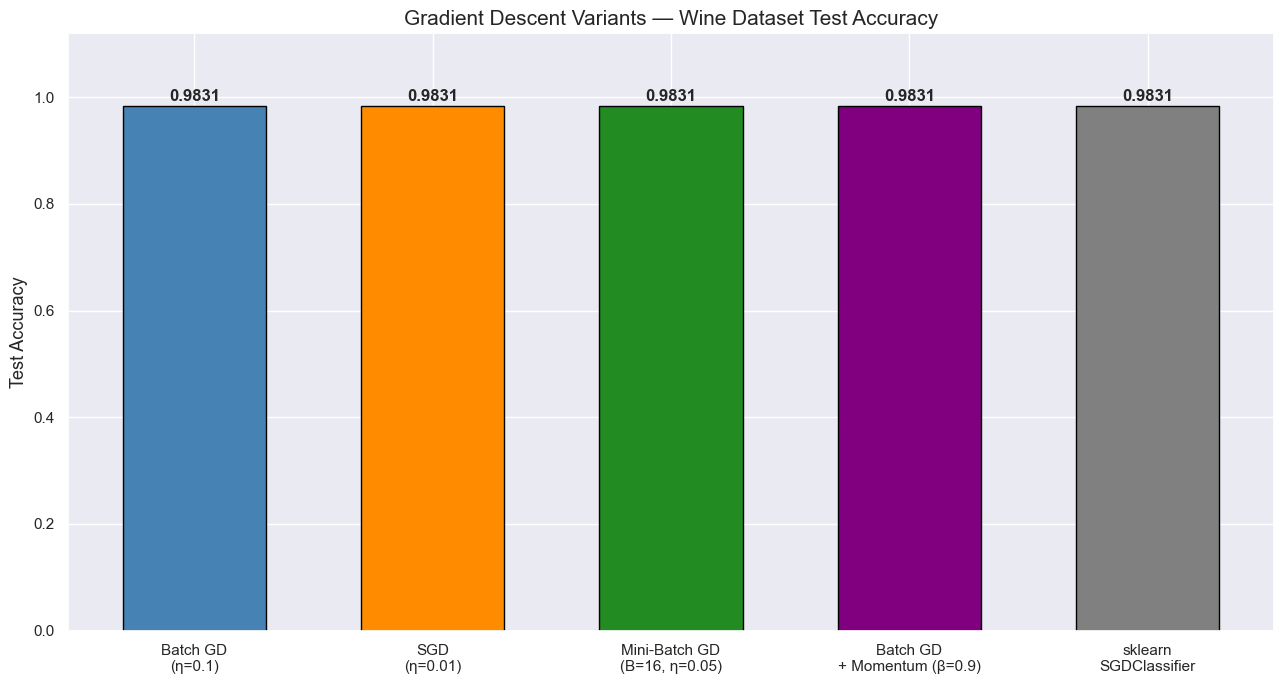


Ranking:
  1. Batch GD (η=0.1)                       0.9831
  2. SGD (η=0.01)                           0.9831
  3. Mini-Batch GD (B=16, η=0.05)           0.9831
  4. Batch GD + Momentum (β=0.9)            0.9831
  5. sklearn SGDClassifier                  0.9831


In [18]:
results = {
    "Batch GD\n(η=0.1)": test_acc_batch,
    "SGD\n(η=0.01)": test_acc_sgd,
    "Mini-Batch GD\n(B=16, η=0.05)": test_acc_mb,
    "Batch GD\n+ Momentum (β=0.9)": test_acc_mom,
    "sklearn\nSGDClassifier": sklearn_acc,
}

colors = ["steelblue", "darkorange", "forestgreen", "purple", "gray"]

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.bar(results.keys(), results.values(),
              color=colors, edgecolor="black", width=0.6)

for bar, acc in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{acc:.4f}",
            ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_ylim(0, 1.12)
ax.set_ylabel("Test Accuracy", fontsize=13)
ax.set_title("Gradient Descent Variants — Wine Dataset Test Accuracy", fontsize=15)
plt.tight_layout()
plt.show()

print("\nRanking:")
for rank, (name, acc) in enumerate(
        sorted(results.items(), key=lambda x: x[1], reverse=True), 1):
    print(f"  {rank}. {name.replace(chr(10), ' '):<38} {acc:.4f}")